In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Improve the appearance of graphs
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv("D:/user/Documents/New folder/depression_data.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (413768, 16)


,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [4]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
['Age', 'Number of Children', 'Income']


In [5]:
# Statistical summary of numerical variables
numerical_summary = df[numerical_columns].describe().T

display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max
Age,413768.0,49.000713,18.158759,18.00,33.00,49.000,65.0,80.00
Number of Children,413768.0,1.298972,1.237054,0.00,0.00,1.000,2.0,4.00
Income,413768.0,50661.707971,40624.100565,0.41,21001.03,37520.135,76616.3,209995.22


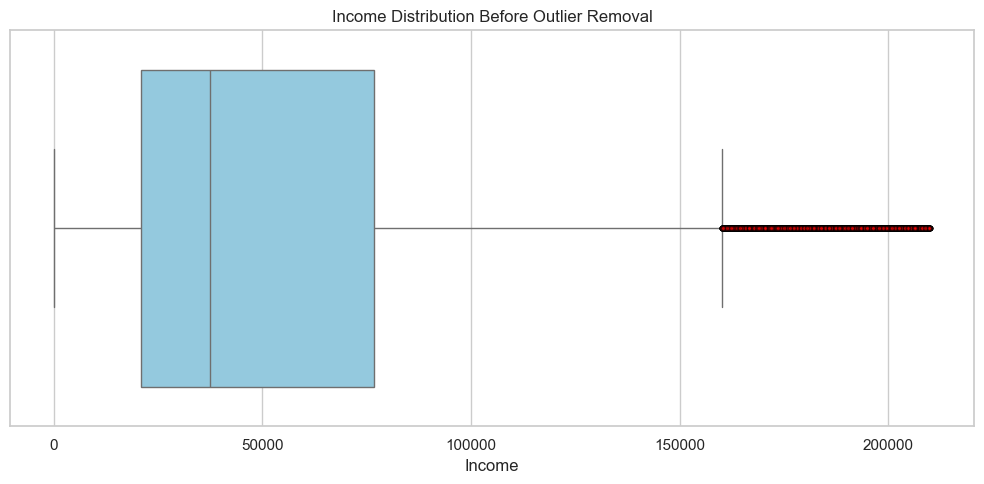

In [6]:
# Create the income boxplot before outlier removal
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["Income"],
    color="skyblue",
    flierprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markersize": 3,
        "alpha": 0.5
    }
)

plt.title("Income Distribution Before Outlier Removal")
plt.xlabel("Income")
plt.tight_layout()
plt.show()

In [7]:
# Calculate the first quartile and third quartile
Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.75)

# Calculate the Interquartile Range
IQR = Q3 - Q1

# Calculate lower and upper boundaries
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"First Quartile (Q1): {Q1:.2f}")
print(f"Third Quartile (Q3): {Q3:.2f}")
print(f"Interquartile Range: {IQR:.2f}")
print(f"Lower Boundary: {lower_bound:.2f}")
print(f"Upper Boundary: {upper_bound:.2f}")

First Quartile (Q1): 21001.03
Third Quartile (Q3): 76616.30
Interquartile Range: 55615.27
Lower Boundary: -62421.88
Upper Boundary: 160039.21


In [8]:
# Create a Boolean condition for income outliers
income_outlier_mask = (
    (df["Income"] < lower_bound) |
    (df["Income"] > upper_bound)
)

# Extract outlier records
income_outliers = df.loc[income_outlier_mask].copy()

# Calculate outlier information
outlier_count = len(income_outliers)
outlier_percentage = (outlier_count / len(df)) * 100

print("Total income outliers:", outlier_count)
print(f"Outlier percentage: {outlier_percentage:.2f}%")

# Display selected outlier records
income_outliers[["Name", "Age", "Employment Status", "Income"]].head(10)

Total income outliers: 5157
Outlier percentage: 1.25%


,Name,Age,Employment Status,Income
15,Daniel Estrada,38,Employed,202449.17
105,Brandi Gates,53,Employed,169400.38
170,Hunter Sullivan,36,Employed,180084.56
193,Amy Scott,64,Employed,193843.44
319,Alan Garcia,31,Employed,177029.40
328,Mary Henry MD,31,Employed,209894.25
342,Matthew Rogers,61,Employed,209701.03
632,Janice Powell,34,Employed,186628.22
664,David Rowe,72,Employed,198181.05
670,William Holmes,41,Employed,191332.82


In [9]:
# Create an outlier summary for all numerical columns
outlier_summary = []

for column in numerical_columns:
    Q1_column = df[column].quantile(0.25)
    Q3_column = df[column].quantile(0.75)
    IQR_column = Q3_column - Q1_column

    lower_column = Q1_column - (1.5 * IQR_column)
    upper_column = Q3_column + (1.5 * IQR_column)

    outlier_condition = (
        (df[column] < lower_column) |
        (df[column] > upper_column)
    )

    number_of_outliers = outlier_condition.sum()
    percentage = (number_of_outliers / len(df)) * 100

    outlier_summary.append({
        "Column": column,
        "Q1": Q1_column,
        "Q3": Q3_column,
        "IQR": IQR_column,
        "Lower Bound": lower_column,
        "Upper Bound": upper_column,
        "Outlier Count": number_of_outliers,
        "Outlier Percentage": percentage
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(
    outlier_summary_df.round({
        "Q1": 2,
        "Q3": 2,
        "IQR": 2,
        "Lower Bound": 2,
        "Upper Bound": 2,
        "Outlier Percentage": 2
    })
)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Age,33.00,65.0,32.00,-15.00,113.00,0,0.00
1,Number of Children,0.00,2.0,2.00,-3.00,5.00,0,0.00
2,Income,21001.03,76616.3,55615.27,-62421.88,160039.21,5157,1.25


In [10]:
# Store the original row count
rows_before = len(df)

# Keep only records within the accepted IQR boundaries
df_cleaned = df.loc[
    (df["Income"] >= lower_bound) &
    (df["Income"] <= upper_bound)
].copy()

# Reset the DataFrame index
df_cleaned.reset_index(drop=True, inplace=True)

# Calculate removal information
rows_after = len(df_cleaned)
rows_removed = rows_before - rows_after
percentage_removed = (rows_removed / rows_before) * 100

print("Rows before outlier removal:", rows_before)
print("Rows removed:", rows_removed)
print("Rows after outlier removal:", rows_after)
print(f"Percentage removed: {percentage_removed:.2f}%")

Rows before outlier removal: 413768
Rows removed: 5157
Rows after outlier removal: 408611
Percentage removed: 1.25%


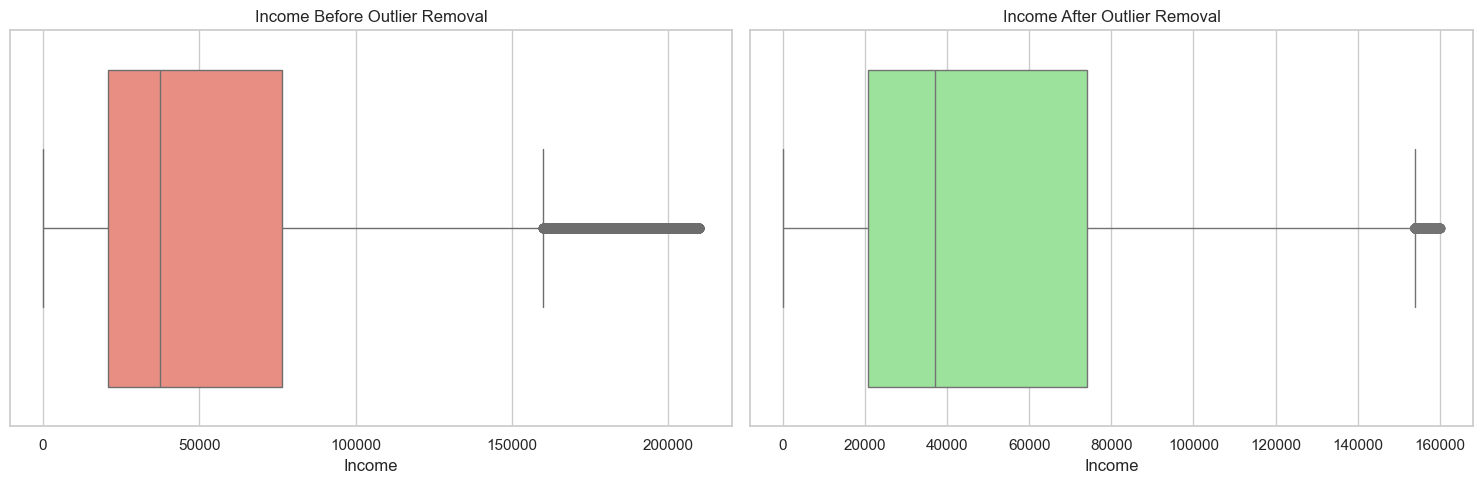

In [11]:
# Create side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before removal
sns.boxplot(
    x=df["Income"],
    color="salmon",
    ax=axes[0]
)
axes[0].set_title("Income Before Outlier Removal")
axes[0].set_xlabel("Income")

# After removal
sns.boxplot(
    x=df_cleaned["Income"],
    color="lightgreen",
    ax=axes[1]
)
axes[1].set_title("Income After Outlier Removal")
axes[1].set_xlabel("Income")

plt.tight_layout()
plt.show()

In [12]:
# Compare income statistics before and after removal
income_comparison = pd.DataFrame({
    "Before Removal": df["Income"].describe(),
    "After Removal": df_cleaned["Income"].describe()
})

display(income_comparison.round(2))

,Before Removal,After Removal
count,413768.00,408611.00
mean,50661.71,48967.61
std,40624.10,37924.58
min,0.41,0.41
25%,21001.03,20742.77
50%,37520.13,37011.40
75%,76616.30,74032.86
max,209995.22,160022.00


In [13]:
# Save the dataset after removing income outliers
df_cleaned.to_csv(
    "depression_data_outliers_removed.csv",
    index=False
)

print("Cleaned dataset saved successfully.")
print("File name: depression_data_outliers_removed.csv")

Cleaned dataset saved successfully.
File name: depression_data_outliers_removed.csv
